In [ ]:
from google.colab import files
uploaded = files.upload()

Saving drone_photo.jpg.jpeg to drone_photo.jpg.jpeg


Shape : (757, 1162, 3)
Dtype : uint8
Size : 2638902


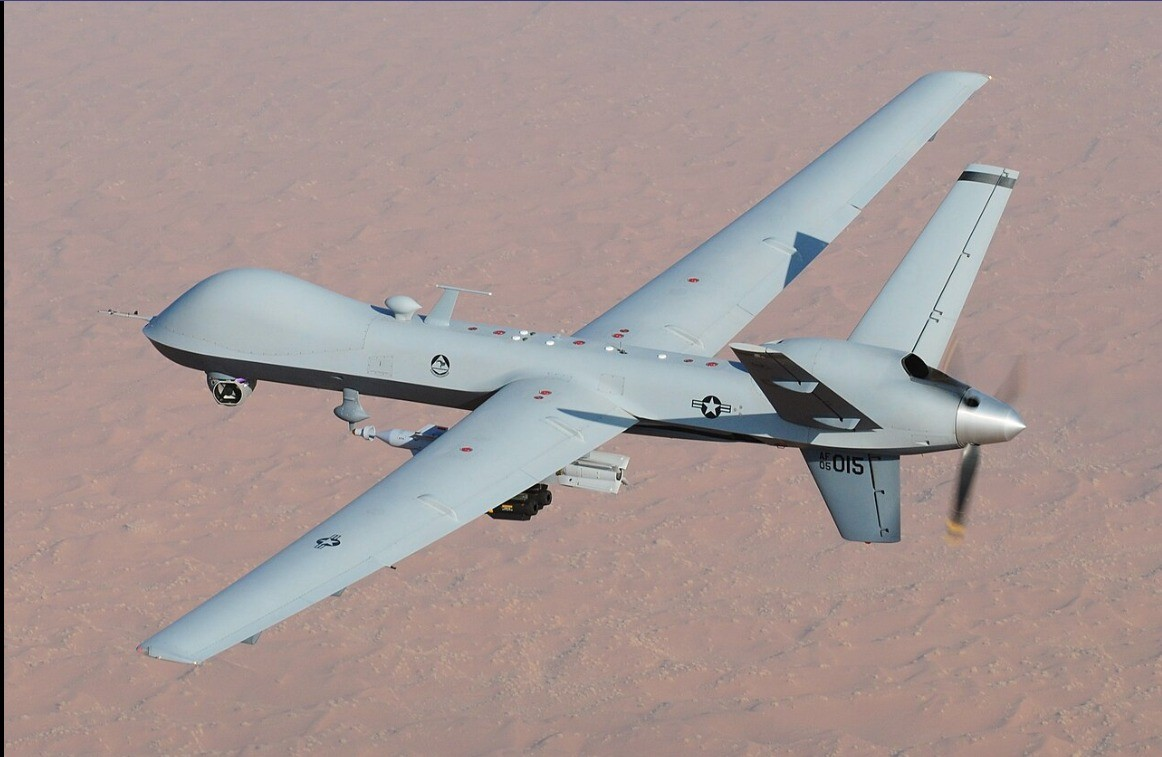

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read image
img = cv2.imread('drone_photo.jpg.jpeg')

# Check if image loaded
if img is None:
    print("Error: Could not load image.")
else:
    # Inspect properties
    print("Shape :", img.shape)
    print("Dtype :", img.dtype)
    print("Size :", img.size)

    # Display image
    cv2_imshow(img)

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [17]:
from google.colab import files
uploaded = files.upload()

Saving report.jpg.jpeg to report.jpg (2).jpeg


Image Size: 555972
Original Image


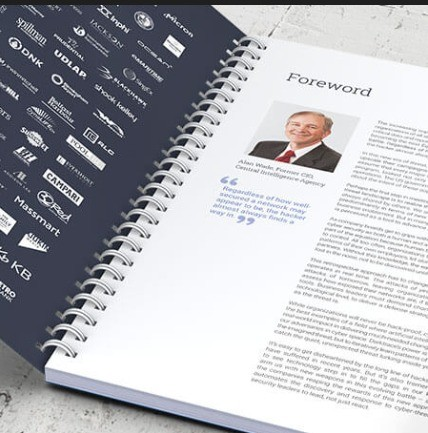

Grayscale


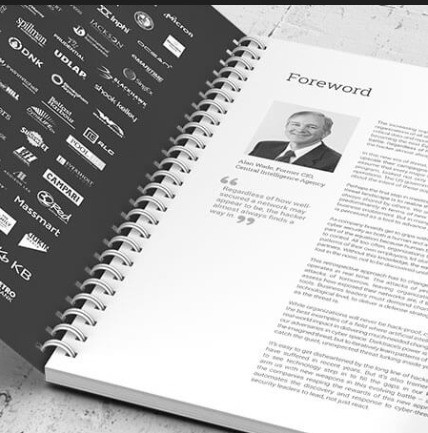

Blurred


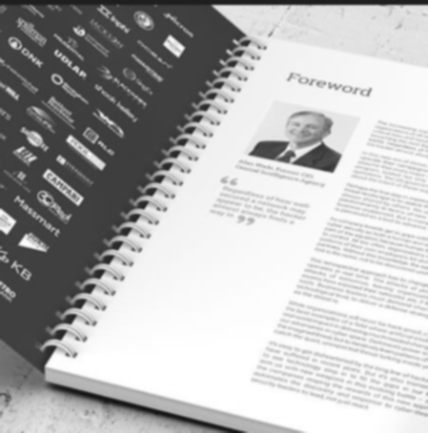

Sharpened


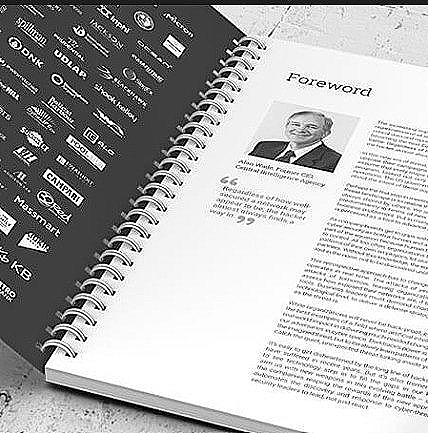

Threshold


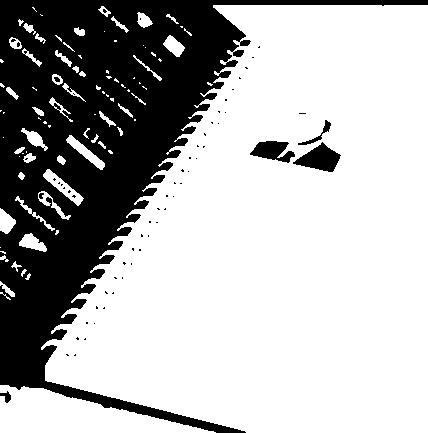

Opening


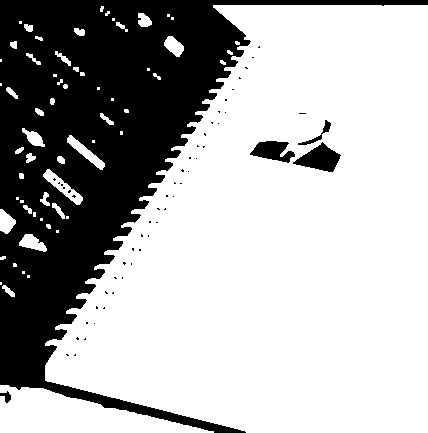

Closing


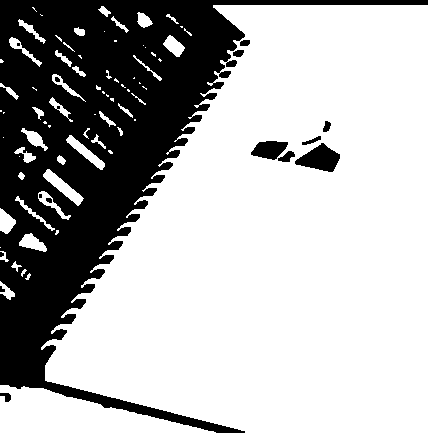

In [18]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read image
img = cv2.imread('report.jpg.jpeg')

if img is None:
    print("Image not found. Please upload report.jpg")

else:

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Sharpening Kernel
    kernel = np.array([
        [0,-1,0],
        [-1,5,-1],
        [0,-1,0]
    ])

    sharp = cv2.filter2D(gray,-1,kernel)

    # Threshold
    _, thresh = cv2.threshold(blur,127,255,cv2.THRESH_BINARY)

    # Morphological kernel
    kernel2 = np.ones((3,3),np.uint8)

    # Opening
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel2)

    # Closing
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel2)

    print("Image Size:", img.size)

    # Show all results
    print("Original Image")
    cv2_imshow(img)

    print("Grayscale")
    cv2_imshow(gray)

    print("Blurred")
    cv2_imshow(blur)

    print("Sharpened")
    cv2_imshow(sharp)

    print("Threshold")
    cv2_imshow(thresh)

    print("Opening")
    cv2_imshow(opening)

    print("Closing")
    cv2_imshow(closing)

In [19]:
from google.colab import files
uploaded = files.upload()

Saving road.jpeg to road.jpeg


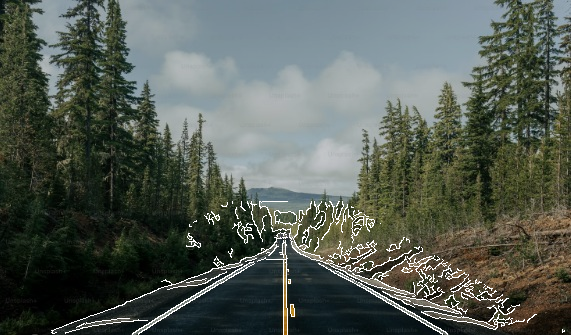

In [20]:
# Scenario: Smart Dashcam Lane Detection
# Imagine you’re building a smart dashcam system for cars that helps drivers stay in their lanes. The dashcam captures frames of
#  the road, and your algorithm processes them step by step:
# - Step 1 – Capture the road scene
# The dashcam takes a snapshot (road.jpg). This is the raw input, just like a driver’s eye view.
# - Step 2 – Focus on essentials
# Convert the image to grayscale. Colors aren’t important for lane detection; what matters are contrasts and shapes.
# - Step 3 – Smooth out distractions
# Apply a Gaussian blur to reduce noise. Think of it as filtering out small pebbles or shadows that could confuse the system.
# - Step 4 – Spot the lane boundaries
# Use Canny edge detection to highlight sharp changes in intensity—these are likely lane markings.
# - Step 5 – Define the driver’s view
# Create a region of interest (ROI) shaped like a trapezoid, covering the part of the road where lanes usually appear. This prevents
#  the system from wasting effort on irrelevant areas like the sky or nearby buildings.
# - Step 6 – Overlay results for feedback
# Combine the detected edges with the original frame. The driver (or tester) now sees lane boundaries highlighted directly on the
# road image.

# 🎯 Teaching Angle
# This scenario shows how computer vision can be applied to real-world problems. Instead of just running code, learners can imagine
# themselves designing a lane-assist feature for autonomous vehicles. Each step connects to a practical need: clarity, focus, safety.

import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# ── Step 1: Load dashcam frame ───────────────────────────
frame = cv2.imread('road.jpeg')

# Check if image was loaded successfully
if frame is None:
    print("Error: Could not load image. Please ensure 'road.jpg' exists in the environment and the path is correct.")
    # Exit or handle the error appropriately
    exit()

# ── Step 2: Convert to grayscale ─────────────────────────
gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# ── Step 3: Reduce noise with Gaussian blur ───────────────
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# ── Step 4: Canny edge detection ─────────────────────────
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

# ── Step 5: Define region of interest (ROI) ───────────────
h, w  = edges.shape
mask  = np.zeros_like(edges)
# Ensure points are integers for cv2.fillPoly
pts   = np.array([[0,h],[w,h],[w*0.6,h*0.6],[w*0.4,h*0.6]], dtype=np.int32)
cv2.fillPoly(mask, [pts], 255)
roi   = cv2.bitwise_and(edges, mask)

# ── Step 6: Overlay on original ──────────────────────────
edges_col = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)
result    = cv2.addWeighted(frame, 0.8, edges_col, 1.0, 0)

cv2_imshow(result)
# cv2.waitKey(0)
# cv2.destroyAllWindows()